## Image processing - food classifier

### Part I - Baseline Evaluation

Using our own collected data as the input to the classification model. Compare the results versus the results from the Food-101 dataset

First test the model is loaded

Model initialized, using device: cuda


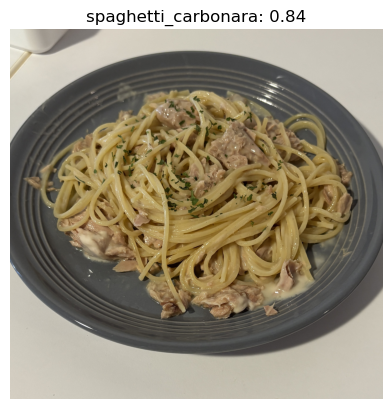

In [1]:
import shutil
import sys
sys.path.insert(0, './src')
from models.classifier import FoodClassifier
from utils import calculate_metrics
import plot

# Initialize the classification model
model = FoodClassifier()

# Model testing, predict a single image
example_image = './data/example.JPG'
results = model.predict_single(example_image)
plot.single_image(example_image, title=f"{results['label']}: {results['confidence']:.2f}")

Run prediction directly on our collected dataset as the baseline

Loaded 44 images from ./data/raw
Predicted 44 images in 10.65s


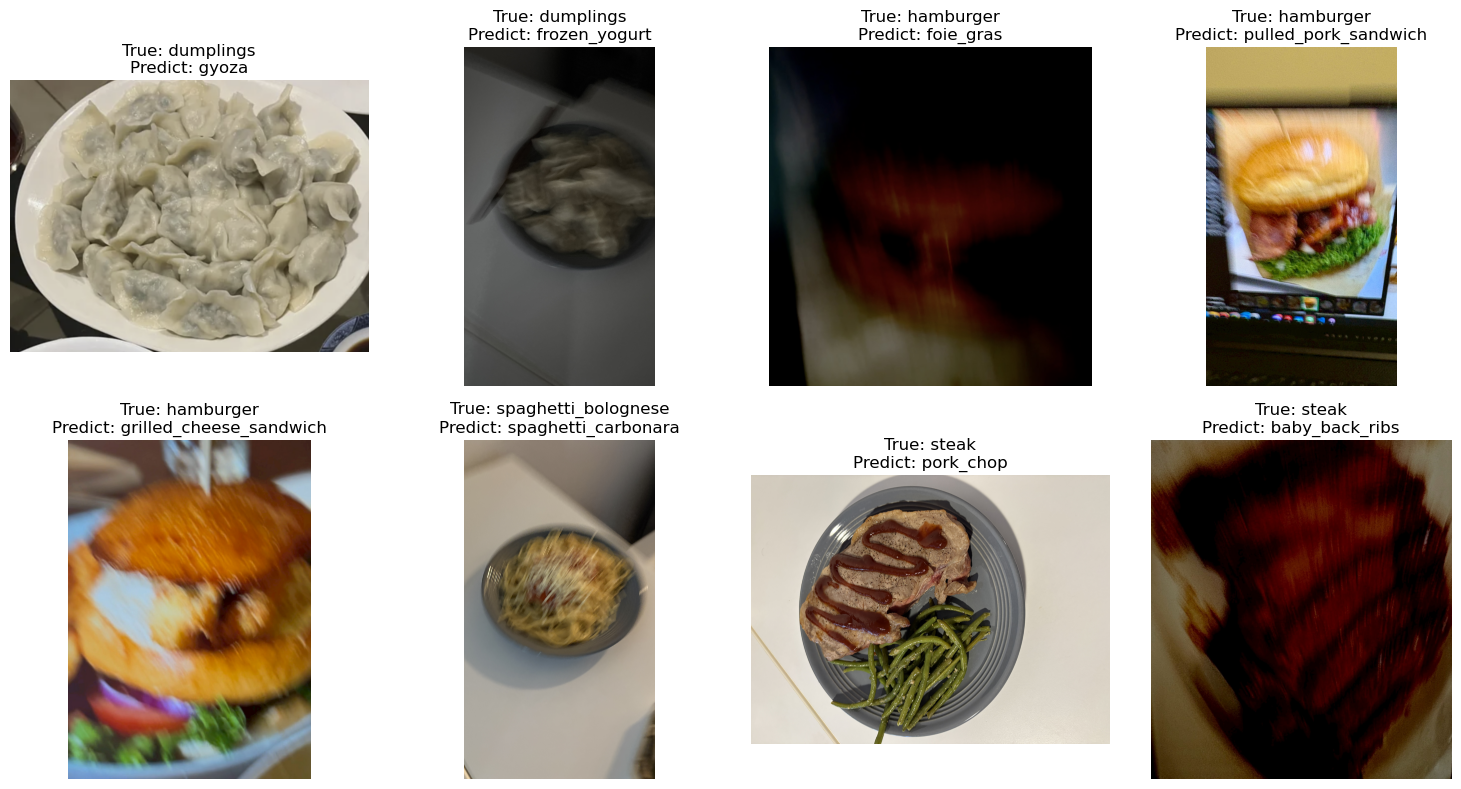

{'accuracy': 0.7954545454545454, 'f1_score': 0.8537878787878789}


In [2]:
dataset_path = './data/raw'
results = model.predict_folder(dataset_path)
plot.wrong_predictions(results, folder = dataset_path)
metrics = calculate_metrics(**results)
print(metrics)

### Part II - Individual Algorithm Evaluation

Process our collected data with the image processing algorithms. Use them as the input to the model

Processing with Lanczos...
Loaded 44 images from ./data/preprocessed_downscaling\Lanczos
Predicted 44 images in 7.15s
Metrics for Lanczos: {'accuracy': 0.75, 'f1_score': 0.8201790633608816}


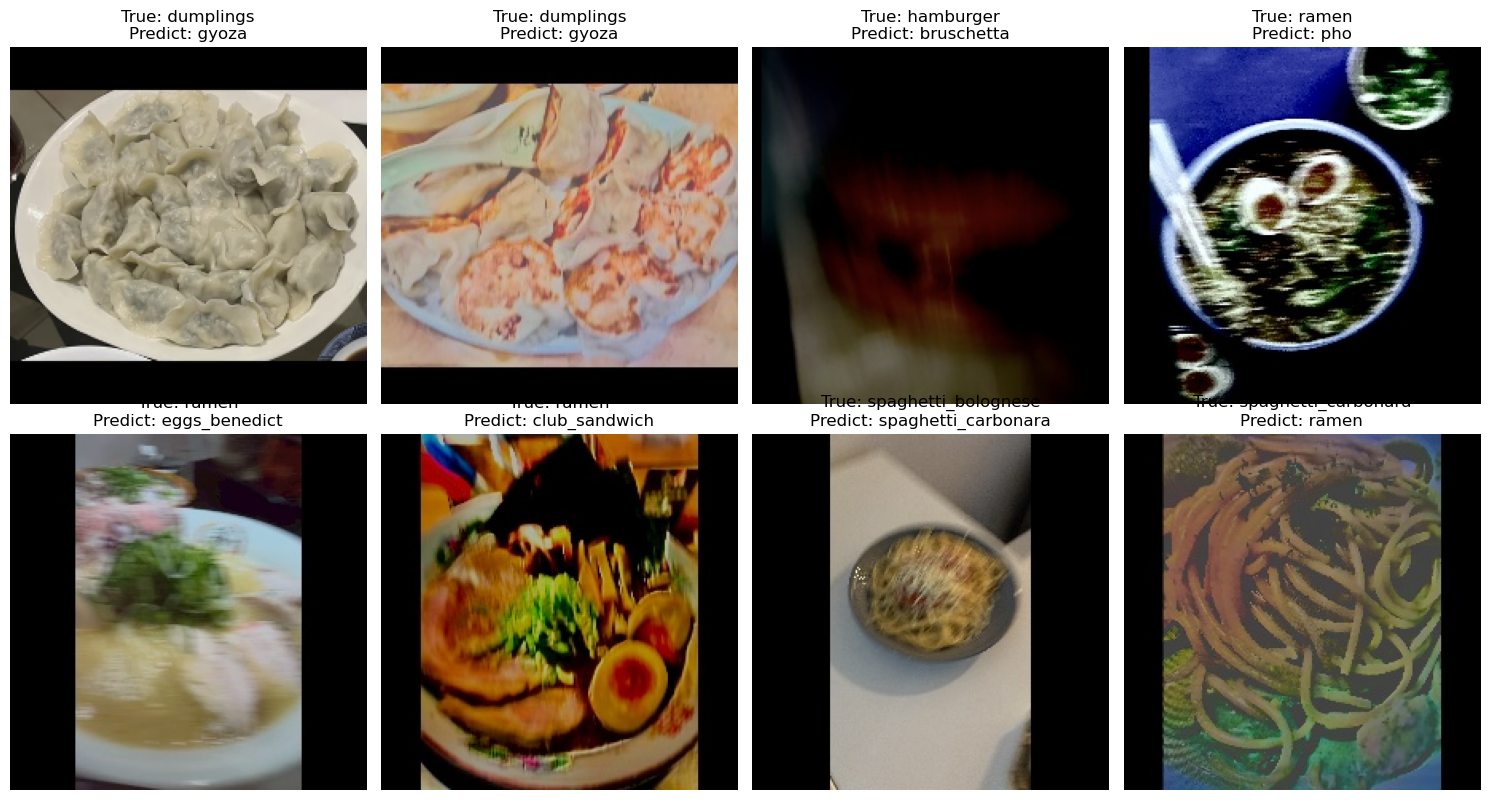

Processing with Lanczos_SAID...
[INFO] Loading SAID model 'SAID_Lanczos' from c:\Users\Austin Chen\Desktop\UCSD\2025_Fall\ECE253\Project\ECE253-food-classification\src\preprocessing\..\..\SAID\pretrained_models\SAID_Lanczos.pth


c:\Users\Austin Chen\Desktop\UCSD\2025_Fall\ECE253\Project\ECE253-food-classification\./src\preprocessing\downscaling.py:137: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  c

In [ ]:
import shutil
from preprocessing.downscaling import downscale_lanczos_224, downscale_lanczos_said_224, downscale_dpid_224
from project_utils import preprocess_folder
import os

base_output_dir = './data/preprocessed_downscaling'

# 定義下採樣函數列表：Lanczos、Lanczos+SAID、DPID
downscaling_functions = {
    "Lanczos": downscale_lanczos_224,
    "Lanczos_SAID": downscale_lanczos_said_224,
    "DPID": downscale_dpid_224,
}

for name, func in downscaling_functions.items():
    current_output_dir = os.path.join(base_output_dir, name)

    # 確保當前方法的輸出資料夾是空的，或者如果不存在則創建
    if os.path.exists(current_output_dir):
        shutil.rmtree(current_output_dir)
    os.makedirs(current_output_dir)

    print(f"Processing with {name}...")
    preprocess_folder(func, input_dir=dataset_path, output_dir=current_output_dir)
    results = model.predict_folder(current_output_dir)
    metrics = calculate_metrics(**results)
    print(f"Metrics for {name}: {metrics}")
    plot.wrong_predictions(results, folder=current_output_dir)

# 不再清理最終的輸出目錄，以保留處理後的圖片



### Part III - Combination Search

### Part IV - Model Fine-Tuning